# Week 5: Advanced Machine Learning — House Price Prediction

## Objective

The objective of this notebook is to improve house price prediction performance by building, evaluating, and comparing multiple machine learning regression models.

The project will begin with Linear Regression as a baseline model and then evaluate more advanced models, including Decision Tree, Random Forest, and Gradient Boosting Regressors.

Hyperparameter tuning will also be performed on a selected model using GridSearchCV to determine whether its predictive performance can be improved.

The models will be evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [165]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Load the Housing Dataset

In [166]:
housing = pd.read_csv("../data/cleaned/housing_cleaned.csv")

In [167]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [168]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [169]:
housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [170]:
housing.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### Missing Values

The dataset was checked for missing values using `isnull().sum()`. No missing values were found, so no imputation was required.

In [171]:
housing.duplicated().sum()

np.int64(0)

### Duplicate Records

Duplicate records were checked using duplicated().sum(). No duplicate records were found in the dataset.

## Step 5 — Encode Categorical Variables

In [172]:
housing = pd.get_dummies(
    housing,
    drop_first=True,
    dtype=int
)

In [173]:
housing.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


## Step 6 — Separate X and y

In [174]:
X = housing.drop("price", axis=1)

y = housing["price"]

In [175]:
X.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [176]:
y.head()

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

## Step 7 — Train/Test Split

In [177]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [178]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(436, 13)
(109, 13)
(436,)
(109,)


## 8. Baseline Model — Linear Regression

Linear Regression is used as the baseline model for this regression problem. The model provides a reference point against which the performance of the more advanced machine learning models can be compared.

In [179]:
baseline_model = LinearRegression()

# Train the model
baseline_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 235.97, 76778.7 ,1094444.79,..., 629890.57,-126881.82,-413645.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea_yes', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.6e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [180]:
# Make predictions on the test data
baseline_pred = baseline_model.predict(X_test)

## Step 10 — Evaluate the Baseline

In [181]:
# Calculate baseline evaluation metrics
baseline_mae = mean_absolute_error(y_test, baseline_pred)

baseline_mse = mean_squared_error(y_test, baseline_pred)

baseline_rmse = np.sqrt(baseline_mse)

baseline_r2 = r2_score(y_test, baseline_pred)

print(f"MAE: KSh {baseline_mae:,.2f}")
print(f"MSE: {baseline_mse:,.2f}")
print(f"RMSE: KSh {baseline_rmse:,.2f}")
print(f"R² Score: {baseline_r2:.4f}")

MAE: KSh 970,043.40
MSE: 1,754,318,687,330.66
RMSE: KSh 1,324,506.96
R² Score: 0.6529


## Step 11 — Create Our Model Comparison Structure

In [182]:
# Store the baseline model results
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [baseline_mae],
    "MSE": [baseline_mse],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2]
})

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,970043.40392,1.754319e+12,1.324507e+06,0.652924


## Decision Tree Regressor

A Decision Tree Regressor predicts continuous numerical values by recursively splitting the dataset based on feature values. Unlike Linear Regression, a Decision Tree can model non-linear relationships between the input features and house prices.

In [183]:
# Create the Decision Tree model
decision_tree = DecisionTreeRegressor(random_state=42)

# Train the model
decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [184]:
# Make predictions using the Decision Tree
dt_pred = decision_tree.predict(X_test)

In [185]:
# Evaluate the Decision Tree
dt_mae = mean_absolute_error(y_test, dt_pred)

dt_mse = mean_squared_error(y_test, dt_pred)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test, dt_pred)

print(f"MAE: KSh {dt_mae:,.2f}")
print(f"MSE: {dt_mse:,.2f}")
print(f"RMSE: KSh {dt_rmse:,.2f}")
print(f"R² Score: {dt_r2:.4f}")

MAE: KSh 1,195,266.06
MSE: 2,642,802,637,614.68
RMSE: KSh 1,625,669.90
R² Score: 0.4771


In [186]:
# Add Decision Tree results to the comparison table
results.loc[len(results)] = [
    "Decision Tree",
    dt_mae,
    dt_mse,
    dt_rmse,
    dt_r2
]

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
1,Decision Tree,1.195266e+06,2.642803e+12,1.625670e+06,0.477146


### Decision Tree Evaluation

The Decision Tree Regressor achieved an MAE of KSh 1,195,266.06, an MSE of 2.64 × 10¹², an RMSE of KSh 1,625,669.90, and an R² score of 0.4771.

Compared with the Linear Regression baseline, the Decision Tree performed worse on the test set. It produced higher MAE, MSE, and RMSE values and a lower R² score. This indicates that the current untuned Decision Tree did not generalize as well to unseen data as the Linear Regression model.

This result demonstrates that a more complex model does not necessarily provide better predictive performance. Hyperparameter tuning may improve the Decision Tree's ability to generalize to unseen data.

## Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines predictions from multiple Decision Trees. By averaging the predictions of many trees, Random Forest can reduce the variance and overfitting associated with individual Decision Trees.

In [187]:
# Create the Random Forest model
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

Make predictions

In [188]:
# Make predictions using the Random Forest
rf_pred = random_forest.predict(X_test)

In [189]:
# Evaluate the Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE: KSh {rf_mae:,.2f}")
print(f"MSE: {rf_mse:,.2f}")
print(f"RMSE: KSh {rf_rmse:,.2f}")
print(f"R² Score: {rf_r2:.4f}")

MAE: KSh 1,021,546.04
MSE: 1,961,585,044,320.34
RMSE: KSh 1,400,565.97
R² Score: 0.6119


In [190]:
# Add Random Forest results to the comparison table
results.loc[len(results)] = [
    "Random Forest",
    rf_mae,
    rf_mse,
    rf_rmse,
    rf_r2
]

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
1,Decision Tree,1.195266e+06,2.642803e+12,1.625670e+06,0.477146
2,Random Forest,1.021546e+06,1.961585e+12,1.400566e+06,0.611919


### Random Forest Evaluation

The Random Forest Regressor achieved an MAE of KSh 1,021,546.04, an MSE of 1.96 × 10¹², an RMSE of KSh 1,400,565.97, and an R² score of 0.6119.

The Random Forest performed better than the Decision Tree, with lower MAE, MSE, and RMSE and a higher R² score. However, it still performed slightly worse than the Linear Regression baseline, which achieved an MAE of KSh 970,043.40, an RMSE of KSh 1,324,506.96, and an R² score of 0.6529.

Although the Random Forest has better generalization than the individual Decision Tree, its current configuration has not yet surpassed the baseline model. Hyperparameter tuning will be used later to determine whether its performance can be improved.

## Gradient Boosting Regressor

Gradient Boosting Regressor is an ensemble learning algorithm that builds decision trees sequentially. Each new tree attempts to reduce the errors made by the previous trees. This allows the model to capture complex and non-linear relationships between the features and house prices.

The initial Gradient Boosting model is evaluated using the same metrics as the previous models: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [191]:
# Create the Gradient Boosting Regressor
gradient_boosting = GradientBoostingRegressor(
    random_state=42
)

# Train the model
gradient_boosting.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [192]:
# Make predictions using Gradient Boosting
gb_pred = gradient_boosting.predict(X_test)

In [193]:
# Evaluate the Gradient Boosting model
gb_mae = mean_absolute_error(y_test, gb_pred)

gb_mse = mean_squared_error(y_test, gb_pred)

gb_rmse = np.sqrt(gb_mse)

gb_r2 = r2_score(y_test, gb_pred)

print(f"MAE:  {gb_mae:,.2f}")
print(f"MSE: {gb_mse:,.2f}")
print(f"RMSE: {gb_rmse:,.2f}")
print(f"R² Score: {gb_r2:.4f}")

MAE:  961,734.63
MSE: 1,693,306,118,911.06
RMSE: 1,301,270.96
R² Score: 0.6650


### Gradient Boosting Evaluation

The Gradient Boosting Regressor achieved an MAE of 961,734.63, an MSE of 1,693,306,118,911.06, an RMSE of 1,301,270.96, and an R² score of 0.6650.

Compared with the previous models, Gradient Boosting produced the lowest MAE, MSE, and RMSE and the highest R² score. It therefore currently provides the best performance among the models evaluated so far.

The results show that Gradient Boosting was able to capture the relationships in the dataset more effectively than Linear Regression, Decision Tree, and Random Forest.

In [194]:
# Add Gradient Boosting results to the comparison table
results.loc[len(results)] = [
    "Gradient Boosting",
    gb_mae,
    gb_mse,
    gb_rmse,
    gb_r2
]

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
1,Decision Tree,1.195266e+06,2.642803e+12,1.625670e+06,0.477146
2,Random Forest,1.021546e+06,1.961585e+12,1.400566e+06,0.611919
3,Gradient Boosting,9.617346e+05,1.693306e+12,1.301271e+06,0.664995


## Model Comparison

The performance of the baseline and advanced regression models is compared using MAE, MSE, RMSE, and R² Score. Lower values are preferred for MAE, MSE, and RMSE, while a higher value is preferred for R² Score.

In [195]:
# Sort models by R² Score
results.sort_values(by="R2", ascending=False)

,Model,MAE,MSE,RMSE,R2
3,Gradient Boosting,9.617346e+05,1.693306e+12,1.301271e+06,0.664995
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
2,Random Forest,1.021546e+06,1.961585e+12,1.400566e+06,0.611919
1,Decision Tree,1.195266e+06,2.642803e+12,1.625670e+06,0.477146


### R² Score Comparison

The R² scores are visualized to provide a direct comparison of how well each model explains the variation in house prices.

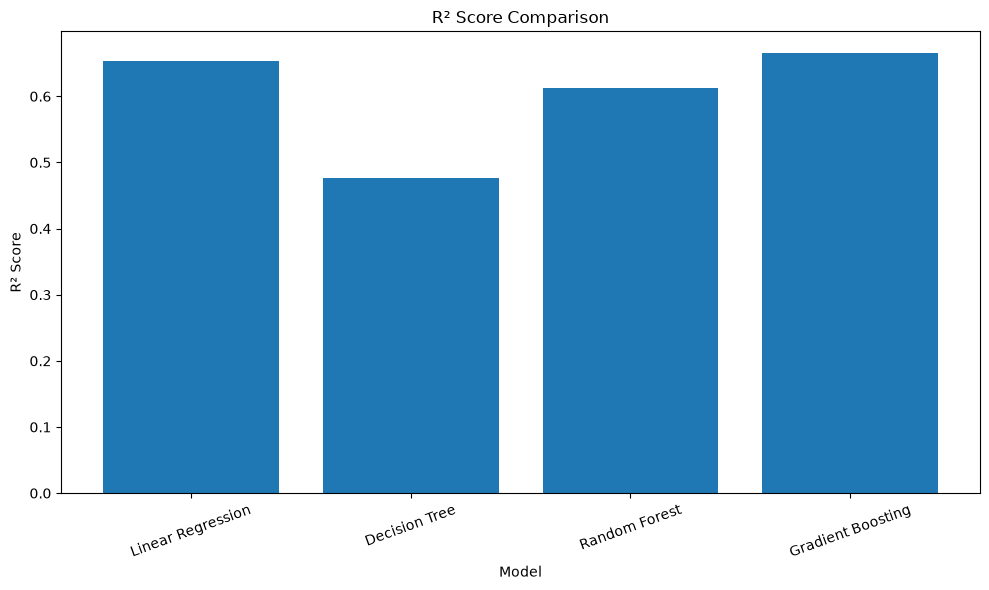

In [196]:
# Plot R² scores for each model
plt.figure(figsize=(10, 6))

plt.bar(results["Model"], results["R2"])

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("R² Score Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

Hyperparameter tuning is used to find a combination of model parameters that improves predictive performance. GridSearchCV tests multiple combinations of hyperparameters using cross-validation and selects the combination that performs best based on the chosen scoring metric.

Gradient Boosting is selected for tuning because it currently has the best performance among the models evaluated.

In [197]:
# Define the hyperparameter grid
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_split": [2, 5]
}

In [198]:
# Create the base Gradient Boosting model
gb_model = GradientBoostingRegressor(random_state=42)

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [199]:
# Perform hyperparameter tuning
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"v

In [200]:
# Display the best hyperparameters
grid_search.best_params_

{'learning_rate': 0.05,
 'max_depth': 2,
 'min_samples_split': 2,
 'n_estimators': 100}

In [201]:
# Display the best cross-validation score
grid_search.best_score_

np.float64(-1196546293173.3958)

### Hyperparameter Tuning Results

GridSearchCV identified the following hyperparameters as the best combination based on cross-validation:

- Learning rate: 0.05
- Maximum depth: 2
- Minimum samples split: 2
- Number of estimators: 100

The selected parameters were then used to evaluate the tuned Gradient Boosting model on the test set.

## Step 14 — Tuned Model Evaluation

In [202]:
# Get the best Gradient Boosting model
tuned_gb = grid_search.best_estimator_

In [203]:
# Make predictions using the tuned model
tuned_gb_pred = tuned_gb.predict(X_test)

In [204]:
# Evaluate the tuned Gradient Boosting model
tuned_gb_mae = mean_absolute_error(y_test, tuned_gb_pred)

tuned_gb_mse = mean_squared_error(y_test, tuned_gb_pred)

tuned_gb_rmse = np.sqrt(tuned_gb_mse)

tuned_gb_r2 = r2_score(y_test, tuned_gb_pred)

print(f"MAE: {tuned_gb_mae:,.2f}")
print(f"MSE: {tuned_gb_mse:,.2f}")
print(f"RMSE: {tuned_gb_rmse:,.2f}")
print(f"R² Score: {tuned_gb_r2:.4f}")

MAE: 1,021,988.20
MSE: 1,937,963,730,283.18
RMSE: 1,392,107.66
R² Score: 0.6166


### Tuned Model Evaluation

The tuned Gradient Boosting model achieved an MAE of 1,021,988.20, an MSE of 1,937,963,730,283.18, an RMSE of 1,392,107.66, and an R² score of 0.6166.

Compared with the untuned Gradient Boosting model, the tuned model produced higher MAE, MSE, and RMSE values and a lower R² score. Therefore, the selected hyperparameters did not improve the model's performance on the test set.

## Final Comparison 

In [205]:
# Add the tuned Gradient Boosting results
results.loc[len(results)] = [
    "Tuned Gradient Boosting",
    tuned_gb_mae,
    tuned_gb_mse,
    tuned_gb_rmse,
    tuned_gb_r2
]

# Display the final comparison
results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
1,Decision Tree,1.195266e+06,2.642803e+12,1.625670e+06,0.477146
2,Random Forest,1.021546e+06,1.961585e+12,1.400566e+06,0.611919
3,Gradient Boosting,9.617346e+05,1.693306e+12,1.301271e+06,0.664995
4,Tuned Gradient Boosting,1.021988e+06,1.937964e+12,1.392108e+06,0.616592


### Final Model Comparison

The final comparison shows that the untuned Gradient Boosting Regressor achieved the best overall performance. It recorded the lowest MAE, MSE, and RMSE and the highest R² score among all evaluated models.

Linear Regression was the second-best model, while Random Forest and Decision Tree performed worse on the test set. The tuned Gradient Boosting model also did not outperform the original Gradient Boosting model.

Therefore, based on the test-set results, the original Gradient Boosting Regressor is selected as the final model for this project.

## Conclusion

This project evaluated multiple machine learning regression models for house price prediction. The workflow included data preparation, feature encoding, feature scaling, train/test splitting, model development, performance evaluation, and hyperparameter tuning.

Four regression models were evaluated: Linear Regression, Decision Tree Regressor, Random Forest Regressor, and Gradient Boosting Regressor. The models were compared using MAE, MSE, RMSE, and R² Score.

Gradient Boosting achieved the best overall performance, with an MAE of 961,734.63, an MSE of 1,693,306,118,911.06, an RMSE of 1,301,270.96, and an R² score of 0.6650. Linear Regression performed slightly below Gradient Boosting, while Random Forest and Decision Tree produced lower predictive performance on the test set.

Hyperparameter tuning was performed on the Gradient Boosting model using GridSearchCV. Although the tuning process identified a different set of hyperparameters, the tuned model did not improve the test-set performance. It achieved an MAE of 1,021,988.20, an MSE of 1,937,963,730,283.18, an RMSE of 1,392,107.66, and an R² score of 0.6166.

Overall, the untuned Gradient Boosting Regressor was selected as the final model because it achieved the lowest MAE, MSE, and RMSE and the highest R² Score among the evaluated models. The results demonstrate that more complex models do not always outperform simpler models and that model performance should be determined through objective evaluation rather than model complexity alone.